In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Reading the dataset
df = pd.read_csv("./data/ai4i2020.csv")

In [3]:
# First look at the data
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# No null values present
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
# Determining Data types
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [6]:
# Categorical Features
for column in ['Type', 'Machine failure']:
    print(df[column].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [7]:
# Description of numerical features
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
# Mean grouping by failres

for column in ['Process temperature [K]', 'Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']:
    print(df.groupby(['Machine failure'])[column].mean())
    print()

Machine failure
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

Machine failure
0    299.973999
1    300.886431
Name: Air temperature [K], dtype: float64

Machine failure
0    1540.260014
1    1496.486726
Name: Rotational speed [rpm], dtype: float64

Machine failure
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

Machine failure
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64



## Deduction:
The machine seems to be failing at low RPM and high Torque instances. The failures due to the change in mean Process and Air Temperatures is insignificant.

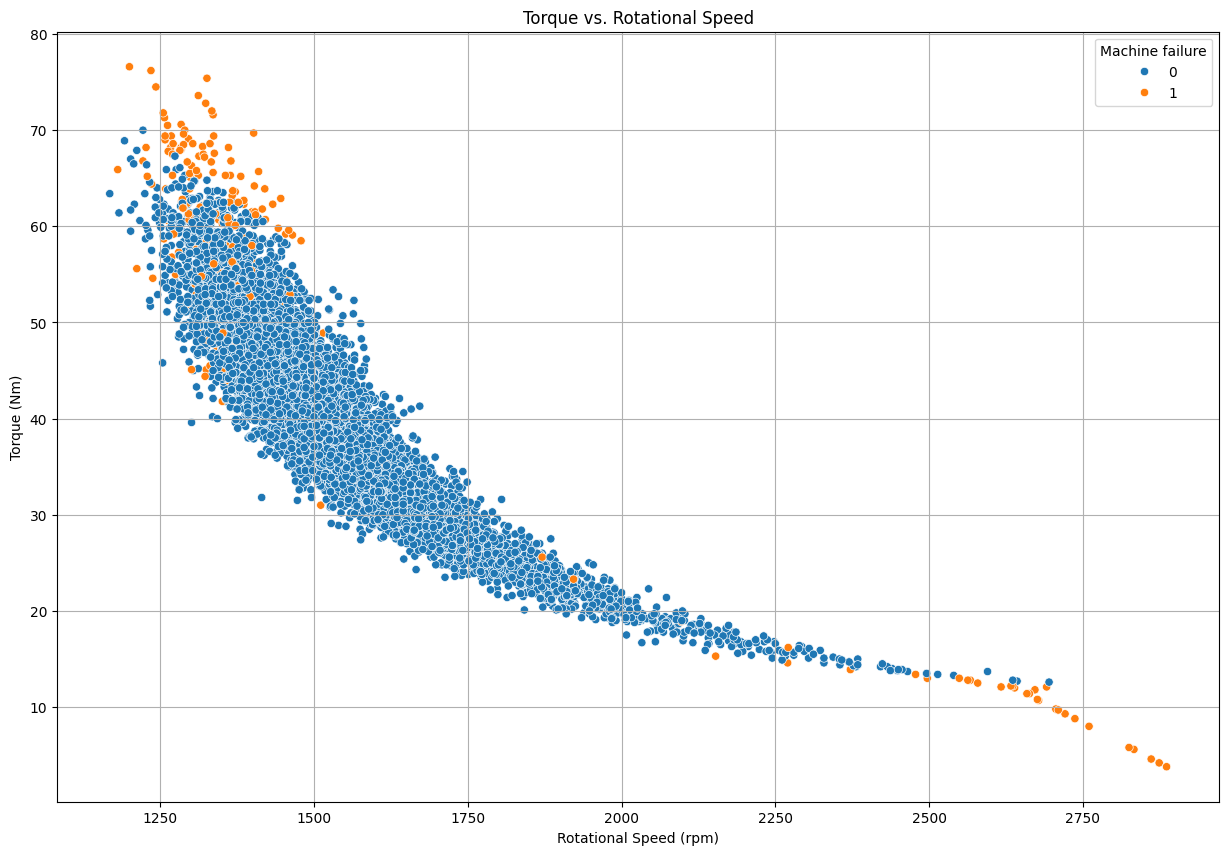

In [9]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', data=df)
plt.title('Torque vs. Rotational Speed')
plt.xlabel('Rotational Speed (rpm)')
plt.ylabel('Torque (Nm)')
plt.grid(True)
plt.savefig('failure_Torque_vs_Rotational_Speed')
plt.show()



## Deduction
The Upper Left Cluster: 
These failures occur when the machine is under massive load / High Torque and Low Rotational Speed. This likely represents Overstrain Failure (the motor literally can't handle the resistance).

The Bottom Right Tail: 
These failures happen at very high rpm and low Torque. This is often Tool Wear Failure or centrifugal instability.

The "Safe Zone": 
The blue mass in the middle is your stable operating region.

# Feature Engineering

The "Type" column represents the quality grade of the product (Low, Medium, High). This is Ordinal Data (H > M > L). Mapping them to 0, 1, 2 so the model understands the hierarchy of quality.

In [10]:

df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Selecting Features X and Targets Y.

Excluding 'udi', 'product_id', and the specific failure types (TWF, HDF, etc.)

In [11]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')


In [12]:
features = ['Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]']

dataset = df[features]
dataset['Machine failure'] = df['Machine failure']
print(dataset.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  
0         42.8                0                0  
1         46.3                3                0  
2         49.4                5                0  
3         39.5                7                0  
4         40.0                9                0  


<Axes: >

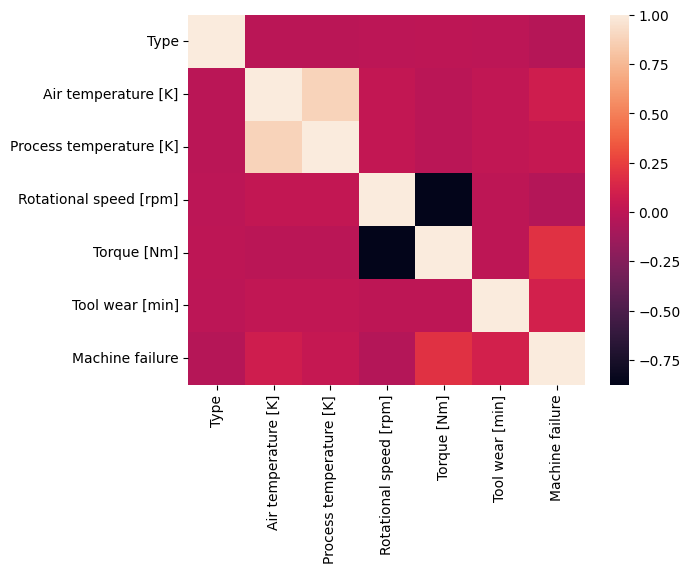

In [13]:
sns.heatmap(dataset.corr())

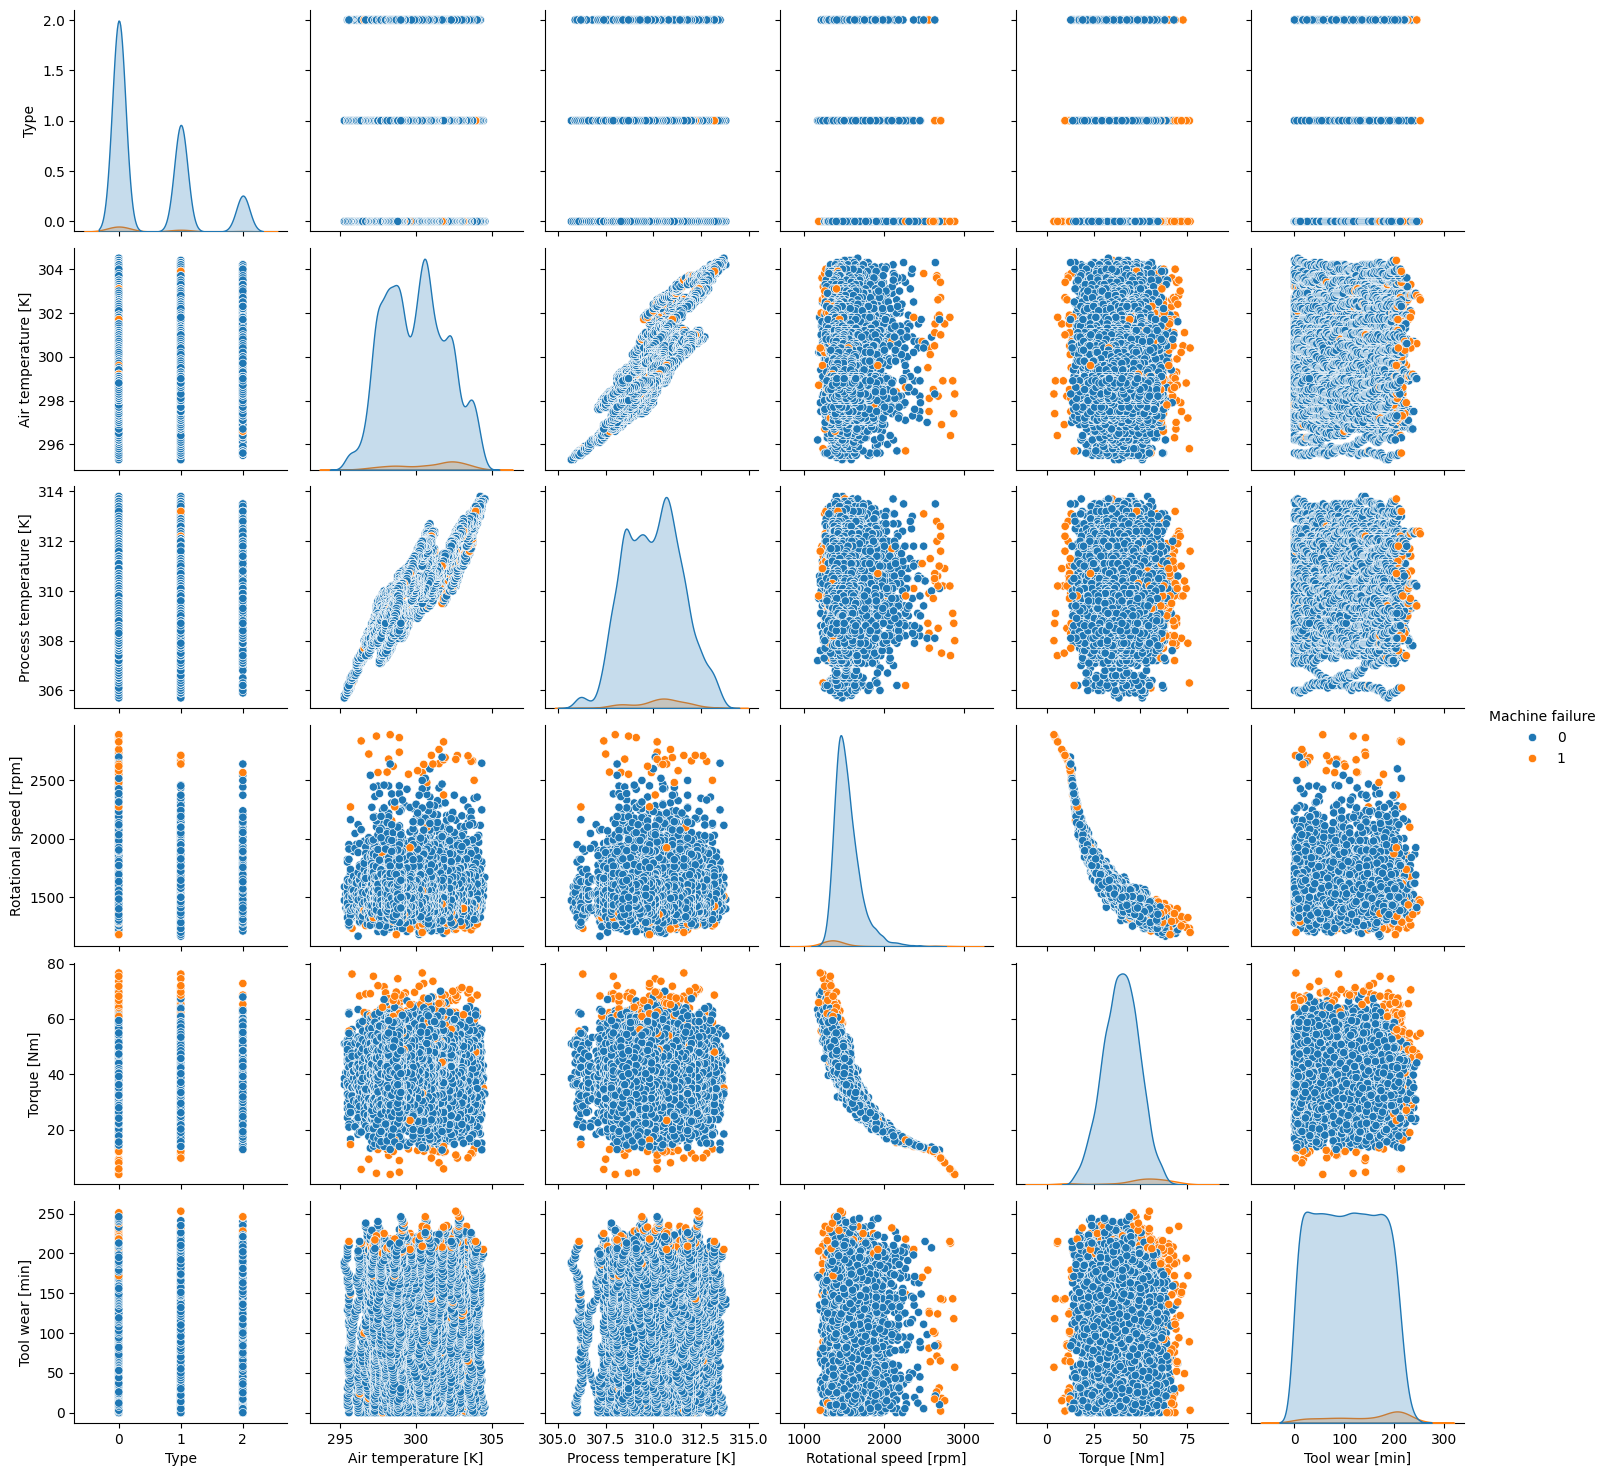

In [14]:
sns.pairplot(dataset, hue="Machine failure")

In [15]:
X = df[features]
Y = df['Machine failure']

In [16]:
# Splitting the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model = DecisionTreeClassifier(max_depth=5, class_weight='balanced')

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
print(classification_report(Y_test, Y_pred))


              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1939
           1       0.25      0.84      0.38        61

    accuracy                           0.92      2000
   macro avg       0.62      0.88      0.67      2000
weighted avg       0.97      0.92      0.94      2000



Recall (0.84): 

This is excellent for a first try! It means the model caught 84% of all actual failures.

Precision (0.25):

 This means, whenever the model is saying Failure, it is wrong 75% of the time.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)

print(classification_report(Y_test, Y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.88      0.48      0.62        61

    accuracy                           0.98      2000
   macro avg       0.93      0.74      0.80      2000
weighted avg       0.98      0.98      0.98      2000



Precision jumped to 0.88 (fantastic!), but your Recall tanked to 0.48. Which means we are now missing 52% of the broken machines. Which means model is now so afraid of being wrong (False Alarms) that it only flags a failure when it is 100% certain, letting half the machines explode in the process.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15, 20],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv = 5, 
    scoring='f1'
    )

grid_search.fit(X_train, Y_train)
print(f"Best Parameters: {grid_search.best_params_}")

best_rf = grid_search.best_estimator_
Y_pred_grid = best_rf.predict(X_test)
print(classification_report(Y_test, Y_pred_grid))

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.65      0.59      0.62        61

    accuracy                           0.98      2000
   macro avg       0.82      0.79      0.80      2000
weighted avg       0.98      0.98      0.98      2000



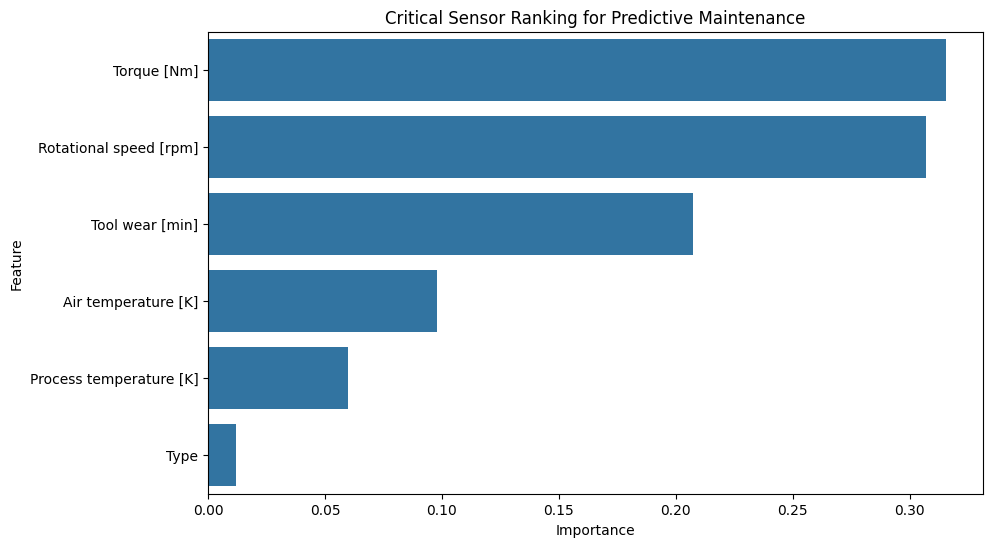

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract importance from the winner
importances = best_rf.feature_importances_
feature_names = features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Critical Sensor Ranking for Predictive Maintenance')
plt.savefig('Critical Sensor Ranking for Predictive Maintenance')
plt.show()